In [279]:
import requests
import pandas as pd
import plotly.express as px
import geopandas as gpd
import time
import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
import seaborn as sns
from sodapy import Socrata
from matplotlib.colorbar import ColorbarBase
import matplotlib.patches as mpatches

In [280]:
url = f'https://data.cdc.gov/api/v3/views/fpsi-y8tj/query.json?$limit=50'

response = requests.get(url)

In [281]:
response.status_code

403

In [282]:
client = Socrata('data.cdc.gov',  None)

In [283]:
results = client.get('fpsi-y8tj', limit=3000)

In [284]:
results_df = pd.DataFrame.from_records(results)

In [285]:
results_df.columns

Index(['geoid', 'name', 'intent', 'period', 'count_sup', 'rate', 'data_as_of',
       'ttm_date_range'],
      dtype='str')

In [286]:
results_df.dtypes

geoid             str
name              str
intent            str
period            str
count_sup         str
rate              str
data_as_of        str
ttm_date_range    str
dtype: object

In [287]:
ttm_rows = results_df[results_df['period'] == 'TTM']
ttm_rows

count_sup_range = ttm_rows[ttm_rows['count_sup'] == '1-9']
count_sup_range

,geoid,name,intent,period,count_sup,rate,data_as_of,ttm_date_range
1672,44,Rhode Island,FA_Homicide,TTM,1-9,-999.0000000000000,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"
1924,50,Vermont,FA_Homicide,TTM,1-9,-999,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"


In [288]:
ttm_rows['intent'].unique()

<ArrowStringArray>
['All_Homicide',  'All_Suicide',      'Drug_OD',    'FA_Deaths',
  'FA_Homicide',   'FA_Suicide']
Length: 6, dtype: str

In [289]:
df = ttm_rows[ttm_rows['intent'].str.startswith('FA')]
df = df[df['count_sup'] != '1-9']

In [290]:
df

,geoid,name,intent,period,count_sup,rate,data_as_of,ttm_date_range
28,01,Alabama,FA_Deaths,TTM,1122,22.00000000000000,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"
35,01,Alabama,FA_Homicide,TTM,466,9.100000000000000,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"
42,01,Alabama,FA_Suicide,TTM,622,12.20000000000000,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"
70,02,Alaska,FA_Deaths,TTM,202,27.50000000000000,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"
77,02,Alaska,FA_Homicide,TTM,36,4.900000000000000,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"
...,...,...,...,...,...,...,...,...
2092,55,Wisconsin,FA_Homicide,TTM,200,3.4,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"
2099,55,Wisconsin,FA_Suicide,TTM,512,8.699999999999999,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"
2127,56,Wyoming,FA_Deaths,TTM,160,27.4,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"
2134,56,Wyoming,FA_Homicide,TTM,21,3.6,2026-02-11T00:00:00.000,"October, 2024 to September, 2025"


In [291]:
df['count_sup'] = pd.to_numeric(df['count_sup'])
df['rate'] = pd.to_numeric(df['rate'])
df['data_as_of'] = pd.to_datetime(df['data_as_of'])

In [292]:
df

,geoid,name,intent,period,count_sup,rate,data_as_of,ttm_date_range
28,01,Alabama,FA_Deaths,TTM,1122,22.0,2026-02-11,"October, 2024 to September, 2025"
35,01,Alabama,FA_Homicide,TTM,466,9.1,2026-02-11,"October, 2024 to September, 2025"
42,01,Alabama,FA_Suicide,TTM,622,12.2,2026-02-11,"October, 2024 to September, 2025"
70,02,Alaska,FA_Deaths,TTM,202,27.5,2026-02-11,"October, 2024 to September, 2025"
77,02,Alaska,FA_Homicide,TTM,36,4.9,2026-02-11,"October, 2024 to September, 2025"
...,...,...,...,...,...,...,...,...
2092,55,Wisconsin,FA_Homicide,TTM,200,3.4,2026-02-11,"October, 2024 to September, 2025"
2099,55,Wisconsin,FA_Suicide,TTM,512,8.7,2026-02-11,"October, 2024 to September, 2025"
2127,56,Wyoming,FA_Deaths,TTM,160,27.4,2026-02-11,"October, 2024 to September, 2025"
2134,56,Wyoming,FA_Homicide,TTM,21,3.6,2026-02-11,"October, 2024 to September, 2025"


In [293]:
df_summary = df.groupby(['geoid','name','intent','period','data_as_of','ttm_date_range']).sum().reset_index()

In [294]:
df_wide = df_summary.pivot(index=['geoid','name','period','data_as_of','ttm_date_range'], columns='intent', values=['count_sup','rate'])
df_wide.columns = [f'{val}_{intent}' for val, intent in df_wide.columns]
df_wide = df_wide.reset_index()
df_wide = df_wide.drop(['period','data_as_of','ttm_date_range'], axis=1)
df_wide = df_wide.reset_index(drop=True)
df_wide

,geoid,name,count_sup_FA_Deaths,count_sup_FA_Homicide,count_sup_FA_Suicide,rate_FA_Deaths,rate_FA_Homicide,rate_FA_Suicide
0,01,Alabama,1122.0,466.0,622.0,22.0,9.1,12.2
1,02,Alaska,202.0,36.0,157.0,27.5,4.9,21.4
2,04,Arizona,1372.0,316.0,986.0,18.5,4.3,13.3
3,05,Arkansas,588.0,186.0,381.0,19.2,6.1,12.4
4,06,California,2760.0,1042.0,1588.0,7.1,2.7,4.1
5,08,Colorado,934.0,169.0,723.0,15.9,2.9,12.3
6,09,Connecticut,187.0,55.0,122.0,5.2,1.5,3.4
7,10,Delaware,120.0,43.0,73.0,11.6,4.2,7.1
8,11,District of Columbia,120.0,107.0,13.0,17.7,15.8,1.9
9,12,Florida,2955.0,760.0,2109.0,13.1,3.4,9.3


In [295]:
import requests
import pandas as pd

url_rankings = "https://everytownresearch.org/rankings/"

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 13_5) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0 Safari/537.36"
}

try:
    page = requests.get(url_rankings, headers=headers)
    page.raise_for_status()
    print(page.text[:500])
except requests.exceptions.RequestException as e:
    print(f"Error fetching the URL: {e}")

<!DOCTYPE html>
<html class="no-js" lang="en-us">

<head>
  <meta charset="utf-8" />
  <meta content="width=device-width, initial-scale=1" name="viewport" />
  <title>Gun Safety Policies Save Lives | Everytown Research &amp; Policy</title>
  <!-- begin Convert Experiences code-->
 <script src="https://cdn-4.convertexperiments.com/v1/js/10034870-10034296.js?environment=production"></script>
  <!-- end Convert Experiences code -->

  <!-- Fundraise Up: the new standard for online giving -->
  <scr


In [296]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(page.text, 'html.parser')

In [297]:
data = []

states = soup.find_all('span', class_= 'rankings-table__state')

for state_tag in states:
    state = state_tag.get_text(strip=True)

    parent = state_tag.find_parent()

    value_tag = parent.find_next('span', class_= 'rankings-tabular-bar__value')

    if value_tag:
        strength = value_tag.contents[-1].strip()
        data.append({'State':state, 'Gun Law Strength':strength})

df = pd.DataFrame(data)
df['Gun Law Strength'] = pd.to_numeric(df['Gun Law Strength']).reset_index(drop=True)
df.sort_values(by = 'Gun Law Strength', ascending = False, inplace=True)
df = df.drop_duplicates().reset_index(drop=True)

bins = [0, 20, 40, 60, 80, 100]
labels = [1, 2, 3, 4, 5]
df['Scaled Gun Law Strength'] = pd.cut(df['Gun Law Strength'], bins, labels=labels, include_lowest=True)
df['Scaled Gun Law Strength'] = df['Scaled Gun Law Strength'].astype(int)

In [301]:
df_subset = df_wide[['name','rate_FA_Deaths','count_sup_FA_Deaths']]
df = df.merge(df_subset, left_on = 'State', right_on = 'name')


In [302]:
max = df['rate_FA_Deaths'].max()
min = df['rate_FA_Deaths'].min()
bin_size = (max - min)/5

bins = [min, min+bin_size, min + 2*bin_size, min+ 3*bin_size, min + 4*bin_size, max]
labels = [1,2,3,4,5]
df['Scaled FA Death'] = pd.cut(df['rate_FA_Deaths'], bins, labels=labels, include_lowest=True)
df['Scaled FA Death'] = df['rate_FA_Deaths'].astype(int)

In [338]:
df.dtypes

State                          str
Gun Law Strength           float64
Scaled Gun Law Strength      int64
name_x                         str
rate_FA_Deaths_x           float64
count_sup_FA_Deaths_x      float64
name_y                         str
rate_FA_Deaths_y           float64
count_sup_FA_Deaths_y      float64
name                           str
rate_FA_Deaths             float64
count_sup_FA_Deaths        float64
Scaled FA Death              int64
dtype: object

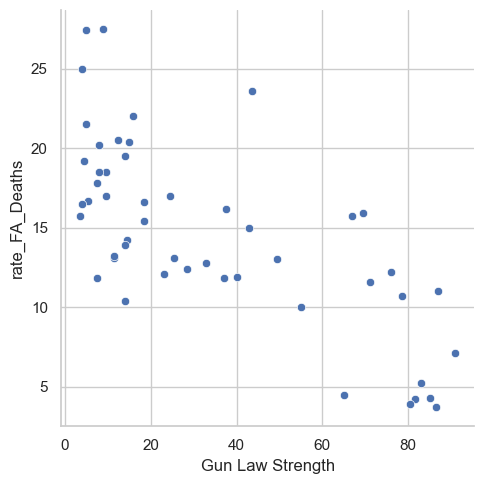

In [303]:
sns.relplot(df, x = 'Gun Law Strength', y = 'rate_FA_Deaths')

In [304]:
map = gpd.read_file('US_State_Boundaries/US_State_Boundaries.shp')

In [305]:
map_and_data = map.merge(df, right_on='State', left_on='NAME', how='right')

In [306]:
map_and_data

,FID,OBJECTID,NAME,STATE_ABBR,STATE_FIPS,ORDER_ADM,MONTH_ADM,DAY_ADM,YEAR_ADM,TYPE,...,name_x,rate_FA_Deaths_x,count_sup_FA_Deaths_x,name_y,rate_FA_Deaths_y,count_sup_FA_Deaths_y,name,rate_FA_Deaths,count_sup_FA_Deaths,Scaled FA Death
0,31,35,California,CA,06,31,September,9,1850,Land,...,California,7.1,2760.0,California,7.1,2760.0,California,7.1,2760.0,7
1,5,5,Illinois,IL,17,21,December,3,1818,Land,...,Illinois,11.0,1380.0,Illinois,11.0,1380.0,Illinois,11.0,1380.0,11
2,36,40,Massachusetts,MA,25,6,February,6,1788,Land,...,Massachusetts,3.7,260.0,Massachusetts,3.7,260.0,Massachusetts,3.7,260.0,3
3,40,44,New York,NY,36,11,July,26,1788,Land,...,New York,4.3,848.0,New York,4.3,848.0,New York,4.3,848.0,4
4,32,36,Connecticut,CT,09,5,January,9,1788,Land,...,Connecticut,5.2,187.0,Connecticut,5.2,187.0,Connecticut,5.2,187.0,5
5,47,53,Hawaii,HI,15,50,August,21,1959,Land,...,Hawaii,4.2,60.0,Hawaii,4.2,60.0,Hawaii,4.2,60.0,4
6,39,43,New Jersey,NJ,34,3,December,18,1787,Land,...,New Jersey,3.9,364.0,New Jersey,3.9,364.0,New Jersey,3.9,364.0,3
7,37,41,Maryland,MD,24,7,April,28,1788,Land,...,Maryland,10.7,659.0,Maryland,10.7,659.0,Maryland,10.7,659.0,10
8,52,59,Washington,WA,53,42,November,11,1889,Land,...,Washington,12.2,955.0,Washington,12.2,955.0,Washington,12.2,955.0,12
9,34,38,Delaware,DE,10,1,December,7,1787,Land,...,Delaware,11.6,120.0,Delaware,11.6,120.0,Delaware,11.6,120.0,11


def largest_polygon_safe(geom):
    """
    Return the largest polygon if MultiPolygon.
    Skip if geom is missing or not a polygon.
    """
    # Check if geometry is valid
    if geom is None or not hasattr(geom, 'geom_type'):
        return geom
    if geom.geom_type == "MultiPolygon":
        return max(geom.geoms, key=lambda g: g.area)
    elif geom.geom_type == "Polygon":
        return geom
    else:
        return geom

# Create a mask for Alaska
mask = map_and_data['State'] == 'Alaska'

# Apply function only to Alaska geometries
map_and_data.loc[mask, 'geometry'] = map_and_data.loc[mask, 'geometry'].apply(largest_polygon)

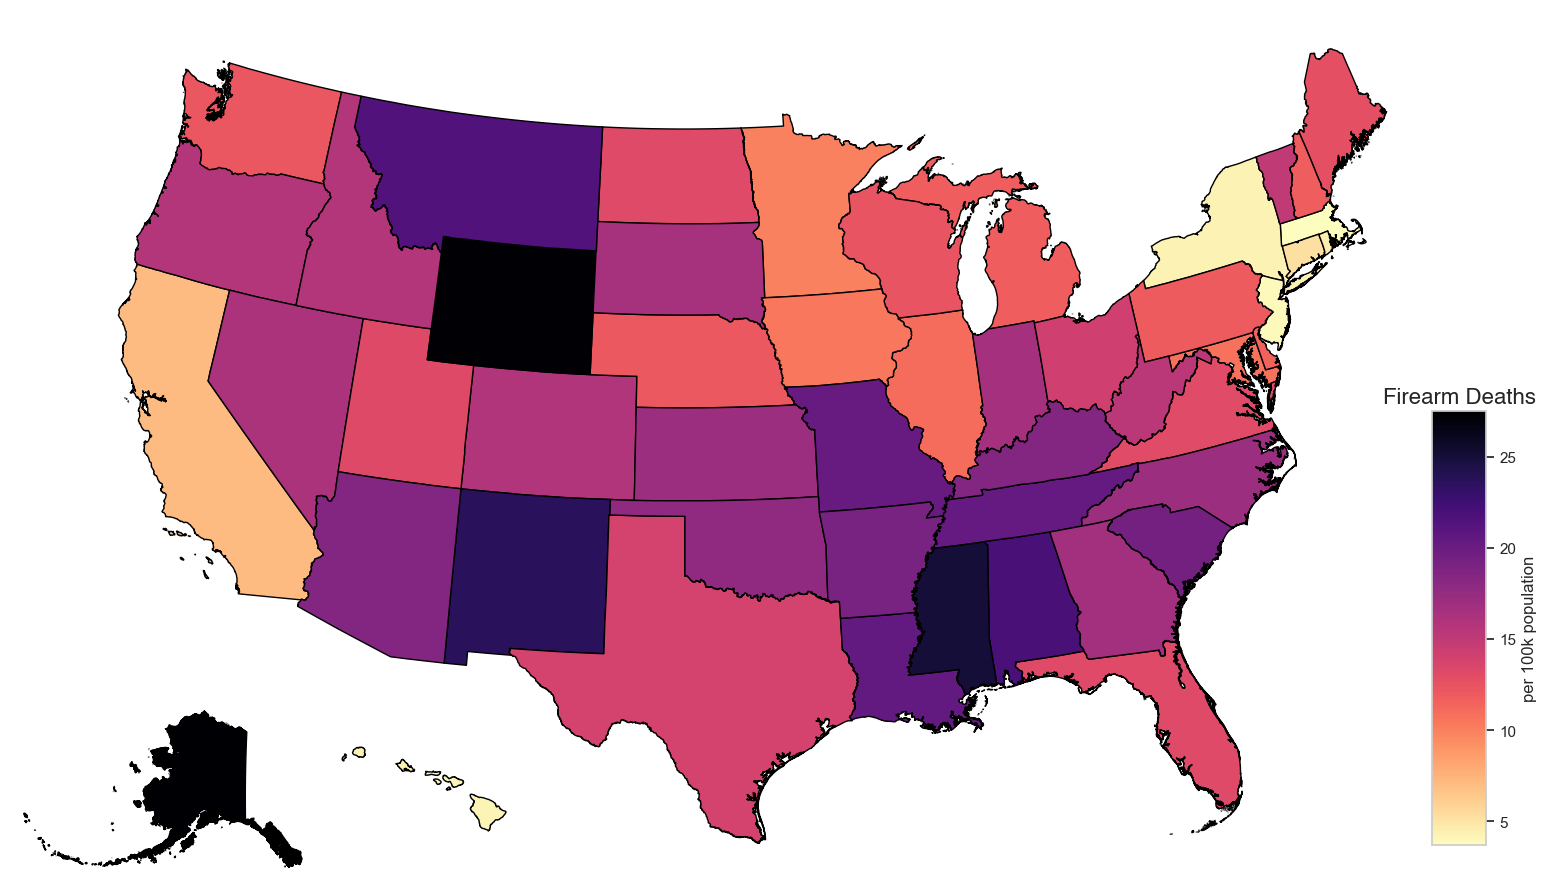

In [327]:
visframe = map_and_data.to_crs(epsg=2163)

vmin = visframe['rate_FA_Deaths'].min()
vmax = visframe['rate_FA_Deaths'].max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.colormaps['magma_r']

fig, ax = plt.subplots(1, figsize=(18,14))
ax.axis('off')

visframe[~visframe['NAME'].isin(['Hawaii','Alaska'])].plot(column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = 'black', linewidth = 1, ax = ax)

akax = fig.add_axes([0.1, 0.17, 0.17, 0.16])
akax.axis('off')
hiax = fig.add_axes([0.28, 0.20, 0.1, 0.1])
hiax.axis('off')

alaska_map = visframe[visframe['NAME'] == 'Alaska']
hawaii_map = visframe[visframe['NAME'] == 'Hawaii']

ak_centroid = alaska_map.geometry.centroid.union_all().centroid
alaska_map['geometry'] = alaska_map['geometry'].rotate(35, origin=(ak_centroid.x, ak_centroid.y))

hi_centroid = hawaii_map.geometry.centroid.union_all().centroid
hawaii_map['geometry'] = hawaii_map['geometry'].rotate(45, origin=(hi_centroid.x, hi_centroid.y))

alaska_map.plot(ax = akax, column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = 'black', linewidth = 1)
hawaii_map.plot(ax = hiax, column = 'rate_FA_Deaths', cmap = cmap, norm = norm, edgecolor = 'black', linewidth = 1)

cbax = fig.add_axes([0.89, 0.21, 0.03, 0.31])
cb = ColorbarBase(cbax, cmap = cmap, norm = norm, orientation = 'vertical', label = 'per 100k population')
cb_title = cbax.set_title('Firearm Deaths', font = 'Helvetica', fontsize = 16, fontweight = 'bold')

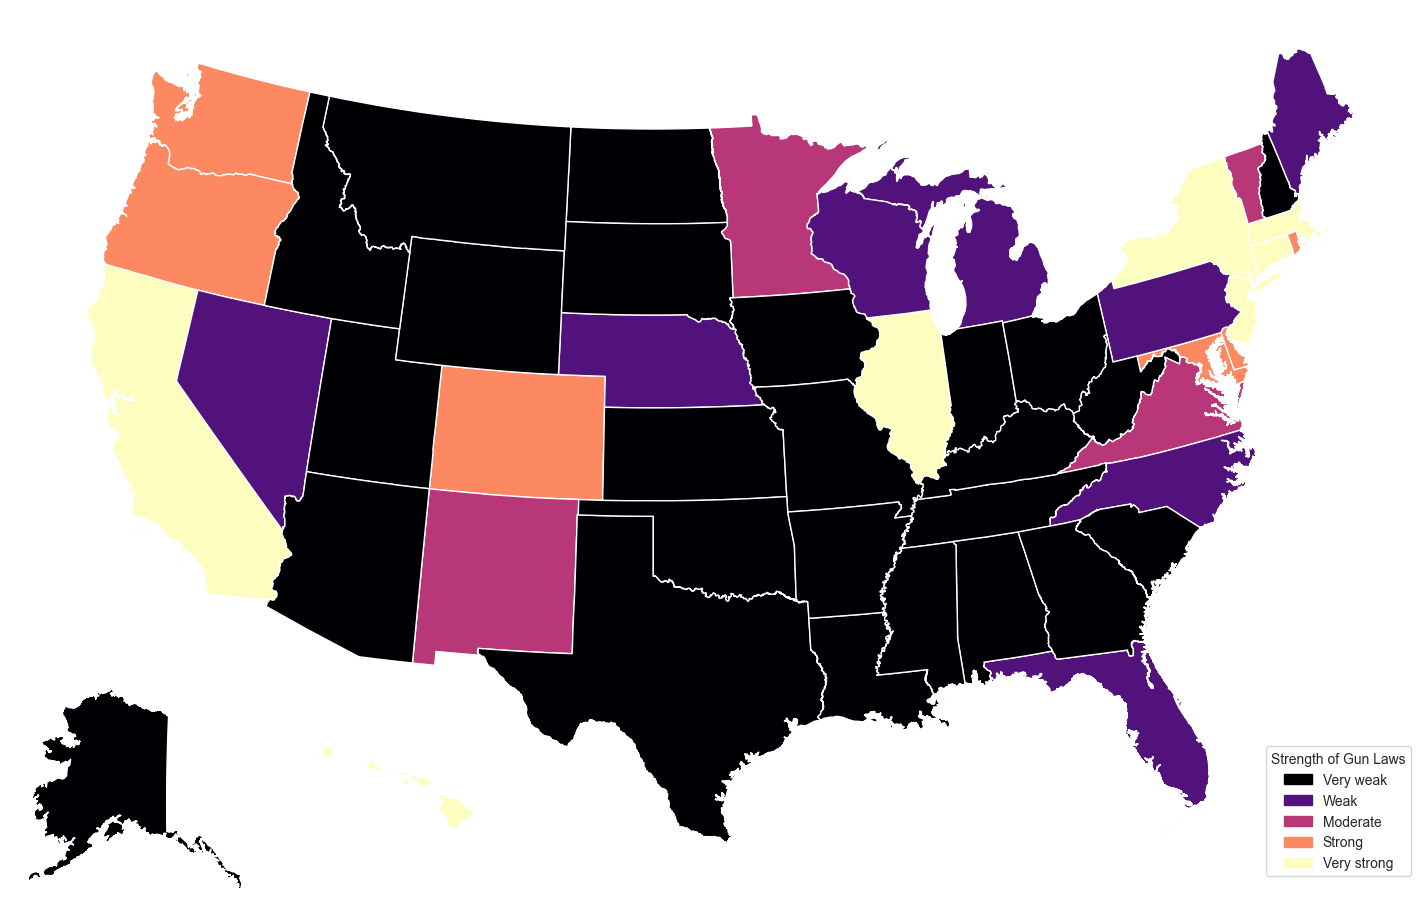

In [229]:
visframe = map_and_data.to_crs(epsg=2163)

vmin = visframe['Scaled Gun Law Strength'].min()
vmax = visframe['Scaled Gun Law Strength'].max()

norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.colormaps['magma']

fig, ax = plt.subplots(1, figsize=(18,14))
ax.axis('off')

visframe[~visframe['NAME'].isin(['Hawaii','Alaska'])].plot(column = 'Scaled Gun Law Strength', cmap = cmap, norm = norm, edgecolor = 'white', linewidth = 1, ax = ax)

akax = fig.add_axes([0.1, 0.17, 0.17, 0.16])
akax.axis('off')
hiax = fig.add_axes([0.28, 0.20, 0.1, 0.1])
hiax.axis('off')

alaska_map = visframe[visframe['NAME'] == 'Alaska']
hawaii_map = visframe[visframe['NAME'] == 'Hawaii']

ak_centroid = alaska_map.geometry.centroid.union_all().centroid
alaska_map['geometry'] = alaska_map['geometry'].rotate(35, origin=(ak_centroid.x, ak_centroid.y))

hi_centroid = hawaii_map.geometry.centroid.union_all().centroid
hawaii_map['geometry'] = hawaii_map['geometry'].rotate(45, origin=(hi_centroid.x, hi_centroid.y))

alaska_map.plot(ax = akax, column = 'Scaled Gun Law Strength', cmap = cmap, norm = norm, edgecolor = 'white', linewidth = 1)
hawaii_map.plot(ax = hiax, column = 'Scaled Gun Law Strength', cmap = cmap, norm = norm, edgecolor = 'white', linewidth = 1)

scale_values = ['Very weak', 'Weak', 'Moderate', 'Strong', 'Very strong']
colors_map = plt.cm.magma([0.0,0.25,0.5,0.75,1.0])
value_to_color = dict(zip(scale_values, colors_map))
patches = [mpatches.Patch(color=color, label=f'{val}') for val, color in value_to_color.items()]
legend = ax.legend(handles=patches, title = 'Strength of Gun Laws', loc = 'lower right')

In [238]:
pearson_corr = df['Gun Law Strength'].corr(df['rate_FA_Deaths'])
print("Pearson correlation:", pearson_corr)

spearman_corr = df['Gun Law Strength'].corr(df['rate_FA_Deaths'], method ='spearman')
print('Spearman correlation:', spearman_corr)

kendall_corr = df['Gun Law Strength'].corr(df['rate_FA_Deaths'], method ='kendall')
print('Kendall correlation:', kendall_corr)

Pearson correlation: -0.7175298125734888
Spearman correlation: -0.7082913077345901
Kendall correlation: -0.5158121757327465


In [244]:
from scipy.stats import pearsonr, spearmanr, kendalltau

r, p = pearsonr(df['Gun Law Strength'], df['rate_FA_Deaths'])
print('Pearson r:', r, 'p-value', p)

rho, p_s = spearmanr(df['Gun Law Strength'], df['rate_FA_Deaths'])
print('Spearman rho:', rho, 'p-value', p_s)

tau, p_k = kendalltau(df['Gun Law Strength'], df['rate_FA_Deaths'])
print('Kendall tau:', tau, 'p-value', p_k)


Pearson r: -0.7175298125734888 p-value 4.533339135004705e-09
Spearman rho: -0.7082913077345901 p-value 8.727002645639571e-09
Kendall tau: -0.5158121757327465 p-value 1.472184482457071e-07


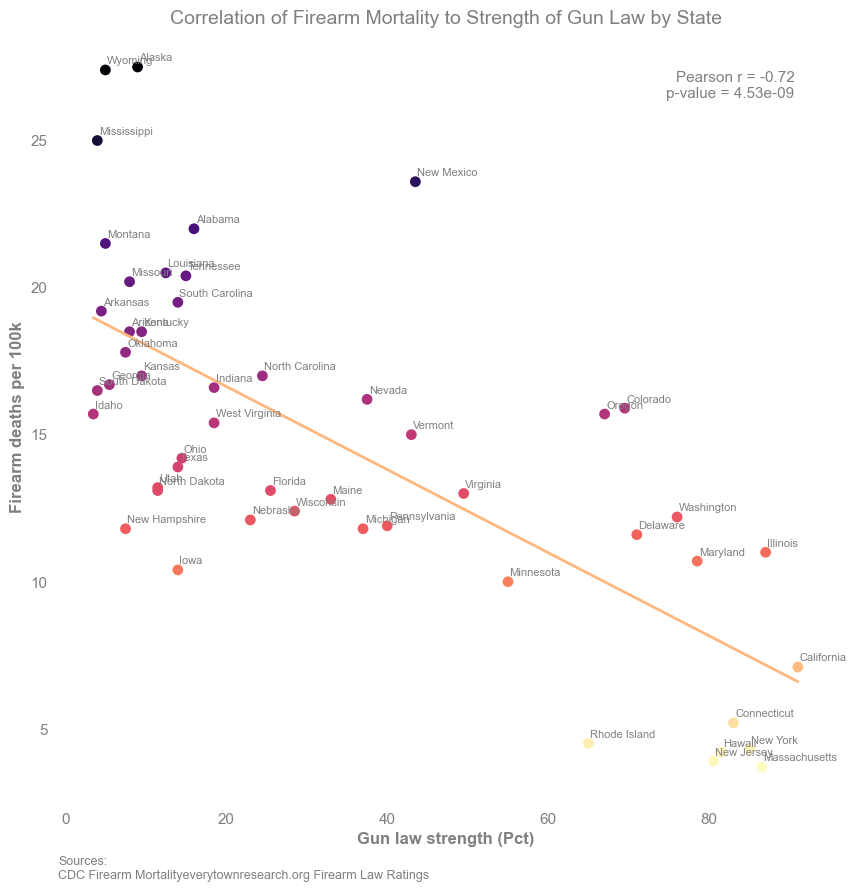

In [358]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,10))

norm = plt.Normalize(df['rate_FA_Deaths'].min(), df['rate_FA_Deaths'].max())
colors = plt.cm.magma_r(norm(df['rate_FA_Deaths']))

ax.scatter(
    df['Gun Law Strength'],
    df['rate_FA_Deaths'],
    c=colors,
    s=60,
    edgecolor = 'none'
)

sns.regplot(
    x = 'Gun Law Strength',
    y = 'rate_FA_Deaths',
    data = df,
    ci = 0.95,
    scatter = False,
    line_kws = {'color': plt.cm.magma(0.85), 'linewidth':2},
    ax = ax
)

for i, row in df.iterrows():
    ax.text(
        row['Gun Law Strength'] + 0.2,   # shift right
        row['rate_FA_Deaths'] + 0.2,     # shift up
        row['State'],
        fontsize=8,
        color='gray'
    )

ax.set_title('Correlation of Firearm Mortality to Strength of Gun Law by State', color='gray', fontsize=14)
ax.set_xlabel('Gun law strength (Pct)', fontweight='bold', color='gray', fontsize=12)
ax.set_ylabel('Firearm deaths per 100k', fontweight='bold', color='gray', fontsize=12)

ax.text(
    0.95, 0.95,
    f"Pearson r = {pearson_corr:.2f}\np-value = {p:.2e}",
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=11,
    color='gray'
)

ax.grid(False)
ax.tick_params(
    axis='both',
    which='both',
    length=4,          # small tick marks
    color='gray',
    labelcolor='gray'  # tick numbers gray
)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.annotate(
    'Sources:\n'
    'CDC Firearm Mortality'
    'everytownresearch.org Firearm Law Ratings',
    xy = (0, -0.1),
    xycoords = 'axes fraction',
    ha='left',
    fontsize=9,
    color='gray'
)

plt.show()